####

# Baseline Model 

DATA MANIPUALTION 

In [900]:
import pandas as pd 
import numpy as np
import os 

DATA VIZUALIZATION

In [901]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px

ML AND PREPROCESSING 

In [902]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.pipeline import Pipeline 
import xgboost as xgb
from pathlib import Path
from tabulate import tabulate 
from joblib import dump, load
import klib 


In [903]:
DATA_PATH = Path('income_evaluation.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(f"{DATA_PATH} not found")
df = pd.read_csv('income_evaluation.csv')
print(f"Loaded Data: {df.shape}")

Loaded Data: (32561, 15)


In [344]:
# DATASET INITIAL SHAPE 
print('====DATASET SHAPE====')
print(df.shape)

# SHOWS FIRST 5 ROWS
print('\n====DISPLAY FIRST 5 ROWS====')
display(df.head())

# DATA INFORMATION 
print('\n====DATA INFORMATION===')
print(df.info())

====DATASET SHAPE====
(32561, 15)

====DISPLAY FIRST 5 ROWS====


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



====DATA INFORMATION===
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB
None


In [682]:
# Drop non-useful or prevent post-event leakage columns
df.drop(['capital-loss', 'capital-gain'], axis=1, inplace=True)

In [683]:
# Features and Target 
X = df.drop('income', axis=1)
y = df['income'].map({" <=50K":0, " >50K":1})

In [684]:
# Train and Test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=9)

# Preprocessing 
Handling missing values (faqat train setdan o'rganadi fill valuelarni)

In [348]:
def tozala_train(df):
    fill_values = {} # Bu bir ombor, tushib qolgan qiymatlarni nima bilan to'ldirdi o'sha bilan saqlaydigan joy
    
    for col in df.columns:
        if df[col].dtype == 'str':
            fill_values[col] = df[col].mode()[0]
            df[col].fillna(fill_values[col], inplace=True)
        else:
            fill_values[col] = df[col].mean()
            df[col].fillna(fill_values[col], inplace=True) 
    return df, fill_values

In [349]:
# For the test
def tozala_test(df, fill_values):
    for col, value in fill_values.items():
        df[col].fillna(value, inplace=True)
    return df

In [350]:
# Working 
X_train, fill_values = tozala_train(X_train)
X_test = tozala_test(X_test, fill_values)


/var/folders/j4/qzhh77r553z1scwnh3mxkx200000gn/T/ipykernel_4190/2314002711.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(fill_values[col], inplace=True)
/var/folders/j4/qzhh77r553z1scwnh3mxkx200000gn/T/ipykernel_4190/2314002711.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series

ENCODING 

In [351]:
# Encoding 
def encodla_train(df, one_hot_thr = 5):
    le_encoders = {}
    one_hot_cols = {}

    for col in df.columns:
        if df[col].dtype == 'str':
            if df[col].nunique() <= one_hot_thr:
                one_hot_cols[col] = df[col].unique()
            else:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col])
                le_encoders[col] = le
    # One Hot on Train
    df = pd.get_dummies(df, columns=one_hot_cols.keys(), drop_first=True,dtype=int)
    return df, le_encoders, one_hot_cols


In [352]:
# For Testing 
def encodla_test(df, le_encoders, one_hot_cols, train_columns):
    # Label encoding with unseen data
    for col, le in le_encoders.items():
        df[col] = df[col].apply(
    lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )
    # One Hot Encoding 
    df = pd.get_dummies(df, columns=one_hot_cols.keys(), drop_first=True, dtype=int)
    # Align columns 
    df = df.reindex(columns=train_columns, fill_value=0)
    return df

In [353]:
# Working on X_train and X_test 
X_train, le_encoders, one_hot_cols = encodla_train(X_train)
X_test = encodla_test(X_test, le_encoders, one_hot_cols, train_columns=X_train.columns)

In [354]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 26048 entries, 10965 to 24958
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       26048 non-null  int64
 1   workclass                 26048 non-null  int64
 2   fnlwgt                    26048 non-null  int64
 3   education                 26048 non-null  int64
 4   education-num             26048 non-null  int64
 5   marital-status            26048 non-null  int64
 6   occupation                26048 non-null  int64
 7   relationship              26048 non-null  int64
 8   hours-per-week            26048 non-null  int64
 9   native-country            26048 non-null  int64
 10  race_ Asian-Pac-Islander  26048 non-null  int64
 11  race_ Black               26048 non-null  int64
 12  race_ Other               26048 non-null  int64
 13  race_ White               26048 non-null  int64
 14  sex_ Male                 26048 non-null  int64
dt

In [355]:
X_test.info()

<class 'pandas.DataFrame'>
Index: 6513 entries, 14551 to 13811
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       6513 non-null   int64
 1   workclass                 6513 non-null   int64
 2   fnlwgt                    6513 non-null   int64
 3   education                 6513 non-null   int64
 4   education-num             6513 non-null   int64
 5   marital-status            6513 non-null   int64
 6   occupation                6513 non-null   int64
 7   relationship              6513 non-null   int64
 8   hours-per-week            6513 non-null   int64
 9   native-country            6513 non-null   int64
 10  race_ Asian-Pac-Islander  6513 non-null   int64
 11  race_ Black               6513 non-null   int64
 12  race_ Other               6513 non-null   int64
 13  race_ White               6513 non-null   int64
 14  sex_ Male                 6513 non-null   int64
dty

SCALING 

In [264]:
# Train Scaling 
def scale_train(df):
    num_cols = df.select_dtypes(include=['int64']).columns
    
    # Initialize scaler and fit on train 
    scaler = StandardScaler()
    df[num_cols] = scaler.fit_transform(df[num_cols])
    return df, scaler, num_cols

In [265]:
# Test Scaling 
def scale_test(df, scaler, num_cols):
    df[num_cols] = scaler.transform(df[num_cols])
    return df

In [266]:
# Woking on Train Scaling and Test Scaling
X_train, scaler, num_cols = scale_train(X_train)
X_test = scale_test(X_test, scaler, num_cols)

In [267]:
X_train.head()#shift+option + pastga bossa duplicate qator bo'ladi

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,hours-per-week,native-country,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Male
16283,-0.554960,0.086121,-0.081650,0.177012,-0.426786,-0.403804,-1.322451,2.196237,-0.034849,0.290648,-0.182673,-0.323644,-0.094089,0.4135,-1.412447
20005,0.403533,0.086121,0.024238,1.213413,-0.037538,-0.403804,0.807358,-0.900445,0.370936,0.290648,-0.182673,-0.323644,-0.094089,0.4135,0.707991
1207,-0.038848,0.086121,-1.030554,-0.341189,1.130207,-0.403804,1.280649,-0.900445,0.127465,0.290648,-0.182673,-0.323644,-0.094089,0.4135,0.707991
21389,-1.439723,0.086121,1.229500,1.213413,-0.037538,0.926565,0.334068,0.957564,-1.252204,0.290648,-0.182673,-0.323644,-0.094089,0.4135,0.707991
12011,0.919645,0.086121,-0.186824,1.213413,-0.037538,-1.734173,-0.139223,-0.281109,-0.034849,-2.018860,-0.182673,-0.323644,-0.094089,0.4135,-1.412447


In [268]:
X_test.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,hours-per-week,native-country,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Male
14551,-1.218532,0.086121,0.208008,-0.341189,1.130207,0.926565,-0.612514,-0.281109,-0.846419,0.290648,-0.182673,-0.323644,-0.094089,0.4135,-1.412447
10060,0.993375,0.086121,0.142583,0.177012,-0.426786,-0.403804,1.753940,-0.900445,3.617214,0.290648,-0.182673,-0.323644,-0.094089,0.4135,0.707991
16768,-0.849881,0.086121,2.172810,0.177012,-0.426786,0.926565,1.753940,0.957564,-0.034849,0.290648,-0.182673,-0.323644,-0.094089,0.4135,0.707991
8138,0.993375,1.463572,-0.252474,0.177012,-0.426786,-1.734173,1.280649,-0.281109,-0.034849,0.290648,-0.182673,-0.323644,-0.094089,0.4135,0.707991
14912,0.477263,0.086121,-0.051236,0.177012,-0.426786,-1.734173,0.334068,1.576900,-0.440634,0.290648,-0.182673,-0.323644,-0.094089,0.4135,-1.412447


# Baseline Model

Logistic Regression

In [269]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Metrics
class_report = classification_report(y_test, y_pred_lr)
confs_matrix = confusion_matrix(y_test, y_pred_lr)
print('===Classificion Report===')
print(class_report)
print("\n===Confusion Matrix===")
print(confs_matrix)

===Classificion Report===
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      7448
           1       0.65      0.42      0.51      2321

    accuracy                           0.81      9769
   macro avg       0.75      0.67      0.70      9769
weighted avg       0.79      0.81      0.79      9769


===Confusion Matrix===
[[6932  516]
 [1348  973]]


Support Vector Machine 

In [270]:
# SVC 
svc = SVC(kernel='linear', C=1.0)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

# Metrics
class_report = classification_report(y_test, y_pred_svc)
confs_matrix = confusion_matrix(y_test, y_pred_svc)
print('===Classificion Report===')
print(class_report)
print("\n===Confusion Matrix===")
print(confs_matrix)

===Classificion Report===
              precision    recall  f1-score   support

           0       0.84      0.94      0.88      7448
           1       0.68      0.40      0.51      2321

    accuracy                           0.81      9769
   macro avg       0.76      0.67      0.70      9769
weighted avg       0.80      0.81      0.79      9769


===Confusion Matrix===
[[7001  447]
 [1382  939]]


K - Nearest Neighbors

In [ ]:
# KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Metrics
class_report = classification_report(y_test, y_pred_knn)
confs_matrix = confusion_matrix(y_test, y_pred_knn)
print('===Classificion Report===')
print(class_report)
print("\n===Confusion Matrix===")
print(confs_matrix)

===Classificion Report===
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      7448
           1       0.62      0.57      0.59      2321

    accuracy                           0.81      9769
   macro avg       0.74      0.73      0.74      9769
weighted avg       0.81      0.81      0.81      9769


===Confusion Matrix===
[[6630  818]
 [1004 1317]]


# No Need to Be Scaled

Decision Tree Classifier

In [308]:
# DT
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Metrics
class_report = classification_report(y_test, y_pred_dt)
confs_matrix = confusion_matrix(y_test, y_pred_dt)
print('===Classificion Report===')
print(class_report)
print("\n===Confusion Matrix===")
print(confs_matrix)

===Classificion Report===
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      4974
           1       0.53      0.55      0.54      1539

    accuracy                           0.78      6513
   macro avg       0.69      0.70      0.70      6513
weighted avg       0.78      0.78      0.78      6513


===Confusion Matrix===
[[4229  745]
 [ 699  840]]


Random Forest Classifier

In [309]:
# RF
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Metrics
class_report = classification_report(y_test, y_pred_rf)
confs_matrix = confusion_matrix(y_test, y_pred_rf)
print('===Classificion Report===')
print(class_report)
print("\n===Confusion Matrix===")
print(confs_matrix)

===Classificion Report===
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      4974
           1       0.66      0.57      0.61      1539

    accuracy                           0.83      6513
   macro avg       0.77      0.74      0.75      6513
weighted avg       0.82      0.83      0.83      6513


===Confusion Matrix===
[[4532  442]
 [ 664  875]]


XGBoost Classifier

In [ ]:
# XGBClassifier
xgb = xgb.XGBClassifier(
    n_estimators=150, 
    learning_rate=0.01,
    max_depth=3, 
    subsample=1,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Metrics
class_report = classification_report(y_test, y_pred_xgb)
confs_matrix = confusion_matrix(y_test, y_pred_xgb)
print('===Classificion Report===')
print(class_report)
print("\n===Confusion Matrix===")
print(confs_matrix)


===Classificion Report===
              precision    recall  f1-score   support

           0       0.84      0.96      0.90      4974
           1       0.77      0.39      0.51      1539

    accuracy                           0.83      6513
   macro avg       0.80      0.68      0.71      6513
weighted avg       0.82      0.83      0.81      6513


===Confusion Matrix===
[[4797  177]
 [ 944  595]]


# Tabulate

Baseline Models Comparision

In [359]:
from tabulate import tabulate

baseline = [
    ['Decision Tree Classifier', 0.78, 0.53, 0.55, 0.54],
    ['Random Forest Classifier', 0.83, 0.66, 0.57, 0.61],
    ['XGBClassifier',0.83, 0.77, 0.39, 0.51],
    ['Logistic Regression',0.81, 0.65, 0.42, 0.51],
    ['Support Vector Machine',0.81, 0.68, 0.40, 0.51],
    ['KNN', 0.81, 0.62, 0.57, 0.59]
    
]
headers = ['Models', 'accuracy', 'precision', 'recall', 'f1-score']
table = tabulate(baseline, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')


+--------------------------+------------+-------------+----------+------------+
| Models                   |   accuracy |   precision |   recall |   f1-score |
+==========================+============+=============+==========+============+
| Decision Tree Classifier |       0.78 |        0.53 |     0.55 |       0.54 |
+--------------------------+------------+-------------+----------+------------+
| Random Forest Classifier |       0.83 |        0.66 |     0.57 |       0.61 |
+--------------------------+------------+-------------+----------+------------+
| XGBClassifier            |       0.83 |        0.77 |     0.39 |       0.51 |
+--------------------------+------------+-------------+----------+------------+
| Logistic Regression      |       0.81 |        0.65 |     0.42 |       0.51 |
+--------------------------+------------+-------------+----------+------------+
| Support Vector Machine   |       0.81 |        0.68 |     0.40 |       0.51 |
+--------------------------+-----------

In [364]:
best_score = max(model[1] for model in baseline)  # this takes the maximum values
best_models = []  # we will store the best models here

for model in baseline:
    # if model[1] equals the best score and model name matches
    if model[1] == best_score and model[0] in ['Random Forest Classifier']:
        # append to best_models list
        best_models.append(model)

for model in best_models:
    print(f'The Best model is {model[0]}, the best f1-score is {model[4]} which is 65%')


The Best model is Random Forest Classifier, the best f1-score is 0.61 which is 65%


# Improvement 

Preprocessing 

As my dataset has not any missing values, I did not use advanced handled missing values method!

In [723]:
df['income'].head(5
)

0     <=50K
1     <=50K
2     <=50K
3     <=50K
4     <=50K
Name: income, dtype: str

# Feature Engineering

In [724]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [904]:
# 1. Edcaution number by percent 
# Hours-per-week --> hours-per-month, hours-per-year
# drop qilinadigna: fnlwgt, capital-loss, and capital-gain 
df['age_education'] = df['age'] * df['education-num']
df['hours_education'] = df['hours-per-week'] * df['education-num']
df['education_level'] = pd.cut(
    df['education-num'],
    bins = [0,8,12,16],
    labels=['low', 'medium', 'high']
)
df['hours_per_month'] = df['hours-per-week'] * 4

In [886]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   age              32561 non-null  int64   
 1   workclass        32561 non-null  str     
 2   fnlwgt           32561 non-null  int64   
 3   education        32561 non-null  str     
 4   education-num    32561 non-null  int64   
 5   marital-status   32561 non-null  str     
 6   occupation       32561 non-null  str     
 7   relationship     32561 non-null  str     
 8   race             32561 non-null  str     
 9   sex              32561 non-null  str     
 10  capital-gain     32561 non-null  int64   
 11  capital-loss     32561 non-null  int64   
 12  hours-per-week   32561 non-null  int64   
 13  native-country   32561 non-null  str     
 14  income           32561 non-null  str     
 15  age_education    32561 non-null  int64   
 16  hours_education  32561 non-null  int64   
 17  educ

In [854]:
df.drop(['capital-gain', 'capital-loss'], axis=1, inplace=True)

In [765]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   age              32561 non-null  int64   
 1   workclass        32561 non-null  str     
 2   fnlwgt           32561 non-null  int64   
 3   education        32561 non-null  str     
 4   education-num    32561 non-null  int64   
 5   marital-status   32561 non-null  str     
 6   occupation       32561 non-null  str     
 7   relationship     32561 non-null  str     
 8   race             32561 non-null  str     
 9   sex              32561 non-null  str     
 10  hours-per-week   32561 non-null  int64   
 11  native-country   32561 non-null  str     
 12  income           32561 non-null  str     
 13  age_education    32561 non-null  int64   
 14  hours_education  32561 non-null  int64   
 15  education_level  32561 non-null  category
 16  hours_per_month  32561 non-null  int64   
dtypes: c

In [905]:
# Features and Target 
X = df.drop('income', axis=1)
y = df['income'].map({" <=50K":0, " >50K":1})

In [906]:
# Train and Test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=9)

In [875]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   age              32561 non-null  int64   
 1   workclass        32561 non-null  str     
 2   fnlwgt           32561 non-null  int64   
 3   education        32561 non-null  str     
 4   education-num    32561 non-null  int64   
 5   marital-status   32561 non-null  str     
 6   occupation       32561 non-null  str     
 7   relationship     32561 non-null  str     
 8   race             32561 non-null  str     
 9   sex              32561 non-null  str     
 10  capital-gain     32561 non-null  int64   
 11  capital-loss     32561 non-null  int64   
 12  hours-per-week   32561 non-null  int64   
 13  native-country   32561 non-null  str     
 14  income           32561 non-null  str     
 15  age_education    32561 non-null  int64   
 16  hours_education  32561 non-null  int64   
 17  educ

In [907]:
class Preprocessing:
    def __init__(self, one_hot_threshold=5):
        self.one_hot_threshold = one_hot_threshold
        self.fill_valeus = {}
        self.label_encoders = {}
        self.one_hot_cols = {}
        self.train_columns = None
        self.scaler = StandardScaler()
        self.num_cols = []

    def _encodla_train(self, df):
        for col in df.columns:
            if df[col].dtype == 'str' or df[col].dtype == 'category':
                if df[col].nunique() <= self.one_hot_threshold:
                    self.one_hot_cols[col] = df[col].unique()
                else:
                    le = LabelEncoder()
                    df[col] = le.fit_transform(df[col])
                    self.label_encoders[col] = le
        df = pd.get_dummies(df, columns=self.one_hot_cols.keys(), drop_first=True, dtype=int)
        return df
    def _encodla_test(self, df):
        for col, le in self.label_encoders.items():
            df[col] = df[col].apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
        df = pd.get_dummies(df, columns=self.one_hot_cols.keys(), drop_first=True, dtype=int)
        df = df.reindex(columns=self.train_columns, fill_value=0)
        return df
    def fit_transform(self, df):
        df = self._encodla_train(df)
        self.num_cols = df.select_dtypes(include=['int64']).columns.tolist()
        # df[self.num_cols] = self.scaler.fit_transform(df[self.num_cols])
        self.train_columns = df.columns 
        return df
    
    def transform(self, df):
        df = self._encodla_test(df)
        # df[self.num_cols] = self.scaler.transform(df[self.num_cols])
        return df

prep = Preprocessing()
X_train = prep.fit_transform(X_train)
X_test = prep.transform(X_test)


In [908]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 26048 entries, 10965 to 24958
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       26048 non-null  int64
 1   workclass                 26048 non-null  int64
 2   fnlwgt                    26048 non-null  int64
 3   education                 26048 non-null  int64
 4   education-num             26048 non-null  int64
 5   marital-status            26048 non-null  int64
 6   occupation                26048 non-null  int64
 7   relationship              26048 non-null  int64
 8   capital-gain              26048 non-null  int64
 9   capital-loss              26048 non-null  int64
 10  hours-per-week            26048 non-null  int64
 11  native-country            26048 non-null  int64
 12  age_education             26048 non-null  int64
 13  hours_education           26048 non-null  int64
 14  hours_per_month           26048 non-null  int64
 1

In [909]:
X_test.info()

<class 'pandas.DataFrame'>
Index: 6513 entries, 14551 to 13811
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       6513 non-null   int64
 1   workclass                 6513 non-null   int64
 2   fnlwgt                    6513 non-null   int64
 3   education                 6513 non-null   int64
 4   education-num             6513 non-null   int64
 5   marital-status            6513 non-null   int64
 6   occupation                6513 non-null   int64
 7   relationship              6513 non-null   int64
 8   capital-gain              6513 non-null   int64
 9   capital-loss              6513 non-null   int64
 10  hours-per-week            6513 non-null   int64
 11  native-country            6513 non-null   int64
 12  age_education             6513 non-null   int64
 13  hours_education           6513 non-null   int64
 14  hours_per_month           6513 non-null   int64
 15

# Log Transform 

High skewness

In [910]:
# Identifying high skewness columns
num_cols = X_train.select_dtypes(include=['int64']).columns
skewness = X_train[num_cols].skew()
# Binary columns as to prevent inf values after transformation
binary_cols = [col for col in num_cols if X_train[col].nunique() == 2]
print(f"Binary columns: {binary_cols}")

encoded_cols = list(prep.label_encoders.keys())


skip_cols = binary_cols + encoded_cols + ['age']


print('===Skewness===')
print(skewness)

# 1-Skewness is higher than 1--log1p
high_skew = skewness[(skewness>1.0) & (~skewness.index.isin(skip_cols))].index
print(f"\nThe columns should be used with Log1p: {list(high_skew)}")

for df in [X_train, X_test]:
    for col in high_skew:
        df[col] = np.log1p(df[col])
print()

Binary columns: ['race_ Asian-Pac-Islander', 'race_ Black', 'race_ Other', 'race_ White', 'sex_ Male', 'education_level_medium', 'education_level_high']
===Skewness===
age                          0.548787
workclass                   -0.740990
fnlwgt                       1.520122
education                   -0.935787
education-num               -0.304649
marital-status              -0.009095
occupation                   0.111013
relationship                 0.785087
capital-gain                11.727486
capital-loss                 4.599193
hours-per-week               0.236521
native-country              -3.673073
age_education                0.809658
hours_education              0.707672
hours_per_month              0.236521
race_ Asian-Pac-Islander     5.271628
race_ Black                  2.773769
race_ Other                 10.572160
race_ White                 -2.012614
sex_ Male                   -0.711856
education_level_medium      -0.500402
education_level_high         1.162

Med skewness

In [911]:
# med-skewness 
med_skew = skewness[(skewness>=0.5) & (skewness<=1.0) & (~skewness.index.isin(skip_cols))].index
print(f"\n===Med Skewness should be used with sqrt: {list(med_skew)}")

for df in [X_train, X_test]:
    for col in med_skew:
        df[col] = np.sqrt(df[col])


===Med Skewness should be used with sqrt: ['age_education', 'hours_education']


Negative skewness

In [912]:
# Negative skewness
neg_skew = skewness[(skewness<-0.5) & (~skewness.index.isin(skip_cols))].index
print(f"The columns should be used with square method: {list(neg_skew)}")

for df in [X_train, X_test]:
    for col in neg_skew:
        df[col] = df[col] ** 2 
print("\n===The Skewness After the Transformation===")
print(X_train[num_cols].skew())

The columns should be used with square method: []

===The Skewness After the Transformation===
age                          0.548787
workclass                   -0.740990
fnlwgt                      -0.828178
education                   -0.935787
education-num               -0.304649
marital-status              -0.009095
occupation                   0.111013
relationship                 0.785087
capital-gain                 3.084591
capital-loss                 4.318096
hours-per-week               0.236521
native-country              -3.673073
age_education                0.157823
hours_education             -0.310591
hours_per_month              0.236521
race_ Asian-Pac-Islander     5.271628
race_ Black                  2.773769
race_ Other                 10.572160
race_ White                 -2.012614
sex_ Male                   -0.711856
education_level_medium      -0.500402
education_level_high         1.162827
dtype: float64


# High Correaltion 


In [913]:
# Future Selection 
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col]>0.8)]
# High correalted features 
print(f"High corr columsn to drop: {to_drop}")

# Drop correlated features 
X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

High corr columsn to drop: ['hours_per_month']


In [914]:
high_corr_pairs = []

for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] is not np.nan and upper.loc[row, col] > 0.8:
            high_corr_pairs.append([row, col, round(upper.loc[row, col], 1)])
corr_table = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
print('Highly correlated feature pairs (correlation > 0.8): ')
print(corr_table)

Highly correlated feature pairs (correlation > 0.8): 
        Feature 1        Feature 2  Correlation
0  hours-per-week  hours_per_month          1.0


 # Heatmap to display among correlations variables

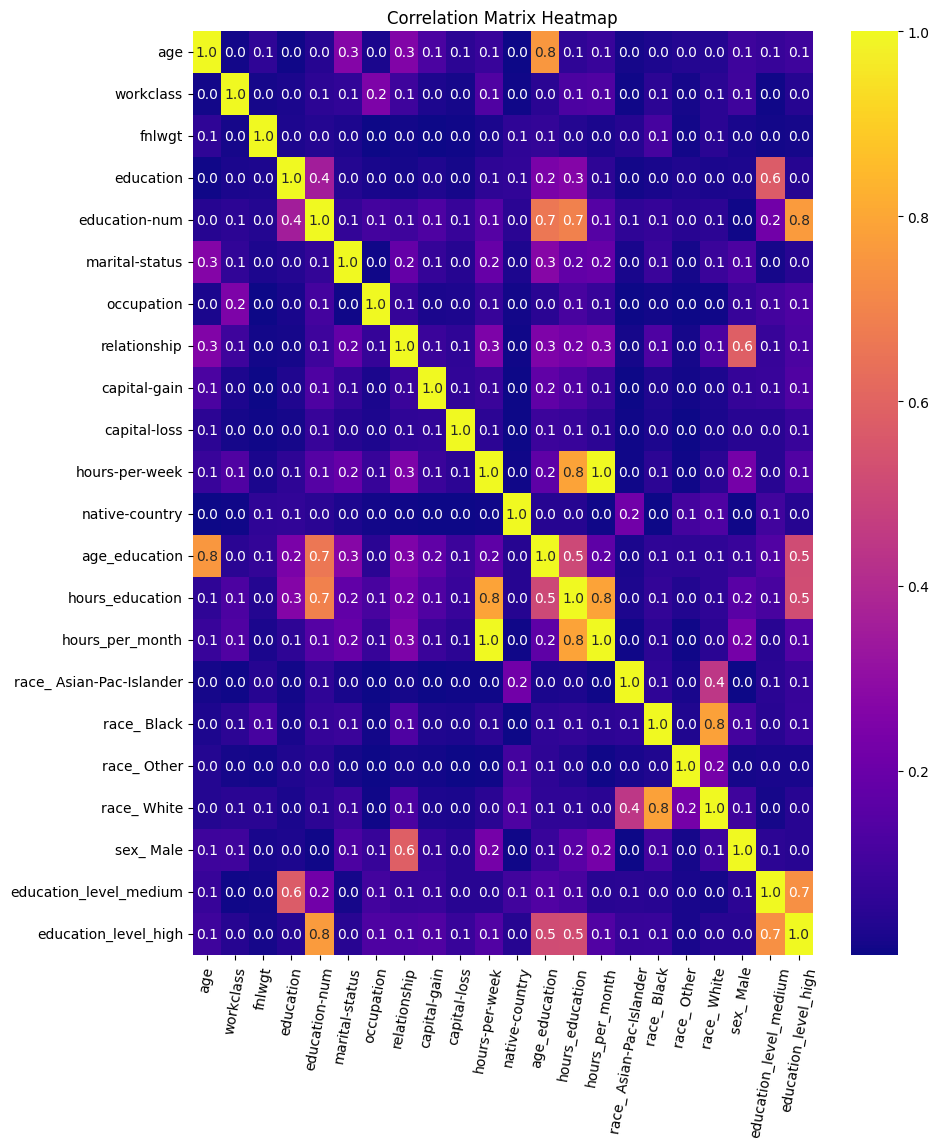

In [897]:
plt.figure(figsize=(10, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.1f', cmap='plasma', cbar=True)
plt.xticks(rotation=80)
plt.title('Correlation Matrix Heatmap')
plt.show()

# Low Variance

In [915]:
from sklearn.feature_selection import VarianceThreshold

threshold = 0.01
selector = VarianceThreshold(threshold = threshold)
selector.fit(X_train)

# low variance columns
low_features_cols = X_train.columns[~selector.get_support()]
print('===Low Features Drop===')
print(list(low_features_cols))

X_train = X_train.drop(columns=low_features_cols)
X_test = X_test.drop(columns=low_features_cols)


===Low Features Drop===
['race_ Other']


# Scaling 

In [899]:
scaler = StandardScaler()
num_cols = X_train.select_dtypes(include=[np.number]).columns
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [837]:
X_train.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,hours-per-week,native-country,age_education,hours_education,race_ Asian-Pac-Islander,race_ Black,race_ White,sex_ Male,education_level_medium,education_level_high
10965,52,4,129177,9,13,6,8,1,20,39,676,260,0,0,1,0,0,1
8893,52,4,245275,0,6,2,8,5,35,39,312,210,0,0,1,0,0,0
20360,50,6,64667,11,9,0,10,1,60,40,450,540,1,0,0,0,1,0
27092,37,4,138192,11,9,2,3,0,45,39,333,405,0,0,1,1,1,0
28983,33,4,339482,11,9,2,3,0,40,39,297,360,0,0,1,1,1,0


In [838]:
X_test.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,hours-per-week,native-country,age_education,hours_education,race_ Asian-Pac-Islander,race_ Black,race_ White,sex_ Male,education_level_medium,education_level_high
14551,22,4,211361,9,13,4,4,1,30,39,286,390,0,0,1,0,0,1
10060,52,4,204402,11,9,2,14,0,85,39,468,765,0,0,1,1,1,0
16768,27,4,420351,11,9,4,14,3,40,39,243,360,0,0,1,1,1,0
8138,52,6,162381,11,9,0,12,1,40,39,468,360,0,0,1,1,1,0
14912,45,4,183786,11,9,0,8,4,35,39,405,315,0,0,1,0,1,0


# Advanced Feature Selection 

Correlation Filtering + Mutual Information 

In [ ]:
# from sklearn.feature_selection import mutual_info_classif
# import pandas as pd 
# corr = df.corr().sort_values(ascending=False)
# mi_scores = pd.Series(
#     mutual_info_classif(X_train, y_train, random_state=42),
#     index=X_train.columns
# ).sort_values(ascending=False)

# print("===Mutual Information Scores====")
# print(mi_scores)

# # choose the threshold
# selected_cols = mi_scores[mi_scores>0.01].index
# print(f"\nChosen columns: {list(selected_cols)}")

# X_train = X_train[selected_cols]
# X_test = X_test[selected_cols]


ValueError: Found input variables with inconsistent numbers of samples: [26030, 26048]

# Non-Linear (Tree-based feature importance)


In [839]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(n_estimators=200, random_state=9)
rf.fit(X_train, y_train)

rf_importances = rf.feature_importances_
rf_df = pd.DataFrame({
    'Feature':X_train.columns,
    'Importance':rf_importances
}).sort_values('Importance', ascending=False)
print("===Random Forest Importance(high->low)===")
print(rf_df)

===Random Forest Importance(high->low)===
                     Feature  Importance
2                     fnlwgt    0.173863
10             age_education    0.141675
7               relationship    0.113482
0                        age    0.098241
11           hours_education    0.089795
6                 occupation    0.077447
5             marital-status    0.064236
8             hours-per-week    0.052588
1                  workclass    0.044890
4              education-num    0.044119
17      education_level_high    0.026677
3                  education    0.017970
9             native-country    0.017321
15                 sex_ Male    0.012519
14               race_ White    0.008543
16    education_level_medium    0.006917
13               race_ Black    0.005789
12  race_ Asian-Pac-Islander    0.003928


In [840]:
rf_threshold = 0.01
rf_selected = rf_df[rf_df['Importance']>rf_threshold]['Feature'].tolist()
print("===Random Forest Selected after putting threshold===")
print(list(rf_selected))

===Random Forest Selected after putting threshold===
['fnlwgt', 'age_education', 'relationship', 'age', 'hours_education', 'occupation', 'marital-status', 'hours-per-week', 'workclass', 'education-num', 'education_level_high', 'education', 'native-country', 'sex_ Male']


In [841]:
X_train = X_train[rf_selected]
X_test = X_test[rf_selected]

In [842]:
# Cheking the shapes that both are the same columns:
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"Columns: {list(X_train.columns)}")

X_train: (26048, 14)
X_test: (6513, 14)
Columns: ['fnlwgt', 'age_education', 'relationship', 'age', 'hours_education', 'occupation', 'marital-status', 'hours-per-week', 'workclass', 'education-num', 'education_level_high', 'education', 'native-country', 'sex_ Male']


# Algorithms 

Logistic Regression

In [814]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Metrics
class_report = classification_report(y_test, y_pred_lr)
confs_matrix = confusion_matrix(y_test, y_pred_lr)
print('===Classificion Report===')
print(class_report)
print("\n===Confusion Matrix===")
print(confs_matrix)

===Classificion Report===
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      4974
           1       0.66      0.42      0.51      1539

    accuracy                           0.81      6513
   macro avg       0.75      0.68      0.70      6513
weighted avg       0.80      0.81      0.80      6513


===Confusion Matrix===
[[4643  331]
 [ 896  643]]


SVM

In [815]:
# SVM
svc = SVC(kernel='linear', C=1.0)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

# Metrics
class_report = classification_report(y_test, y_pred_svc)
confs_matrix = confusion_matrix(y_test, y_pred_svc)
print('===Classificion Report===')
print(class_report)
print("\n===Confusion Matrix===")
print(confs_matrix)

===Classificion Report===
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      4974
           1       0.68      0.38      0.48      1539

    accuracy                           0.81      6513
   macro avg       0.75      0.66      0.68      6513
weighted avg       0.79      0.81      0.79      6513


===Confusion Matrix===
[[4696  278]
 [ 960  579]]


KNN

In [816]:
# KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Metrics
class_report = classification_report(y_test, y_pred_knn)
confs_matrix = confusion_matrix(y_test, y_pred_knn)
print('===Classificion Report===')
print(class_report)
print("\n===Confusion Matrix===")
print(confs_matrix)

===Classificion Report===
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      4974
           1       0.61      0.58      0.60      1539

    accuracy                           0.82      6513
   macro avg       0.74      0.74      0.74      6513
weighted avg       0.81      0.82      0.81      6513


===Confusion Matrix===
[[4411  563]
 [ 640  899]]


# No need to be scaled algorithms 

Decision Tree Classifier

In [843]:
# Decision Tree Classifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Metrics
class_report = classification_report(y_test, y_pred_dt)
confs_matrix = confusion_matrix(y_test, y_pred_dt)
print('===Classificion Report===')
print(class_report)
print("\n===Confusion Matrix===")
print(confs_matrix)

===Classificion Report===
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      4974
           1       0.53      0.55      0.54      1539

    accuracy                           0.78      6513
   macro avg       0.70      0.70      0.70      6513
weighted avg       0.78      0.78      0.78      6513


===Confusion Matrix===
[[4228  746]
 [ 693  846]]


Random Forest Classifier

In [ ]:
# Random Forest Classifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Metrics
class_report = classification_report(y_test, y_pred_rf)
confs_matrix = confusion_matrix(y_test, y_pred_rf)
print('===Classificion Report===')
print(class_report)
print("\n===Confusion Matrix===")
print(confs_matrix)

===Classificion Report===
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      4974
           1       0.66      0.58      0.62      1539

    accuracy                           0.83      6513
   macro avg       0.77      0.74      0.75      6513
weighted avg       0.82      0.83      0.83      6513


===Confusion Matrix===
[[4521  453]
 [ 653  886]]


XGBoost Classifier

In [916]:
# XGBClassifier
xgb = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1,
    max_depth=3, 
    subsample=1,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Metrics
class_report = classification_report(y_test, y_pred_xgb)
confs_matrix = confusion_matrix(y_test, y_pred_xgb)
print('===Classificion Report===')
print(class_report)
print("\n===Confusion Matrix===")
print(confs_matrix)

===Classificion Report===
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      4974
           1       0.78      0.61      0.68      1539

    accuracy                           0.87      6513
   macro avg       0.83      0.78      0.80      6513
weighted avg       0.86      0.87      0.86      6513


===Confusion Matrix===
[[4710  264]
 [ 601  938]]


# Impovement model comparison 

In [918]:
from tabulate import tabulate

improvement = [
    ['Decision Tree Classifier', 0.78, 0.53, 0.55, 0.51],
    ['Random Forest Classifier', 0.83, 0.66, 0.58, 0.62],
    ['XGBClassifier',0.87, 0.78, 0.61, 0.68],
    ['Logistic Regression',0.81, 0.66, 0.42, 0.51],
    ['Support Vector Machine',0.81, 0.68, 0.38, 0.48],
    ['KNN', 0.82, 0.68, 0.58, 0.60]
    
]
headers = ['Models', 'accuracy', 'precision', 'recall', 'f1-score']
table = tabulate(improvement, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')


+--------------------------+------------+-------------+----------+------------+
| Models                   |   accuracy |   precision |   recall |   f1-score |
+==========================+============+=============+==========+============+
| Decision Tree Classifier |       0.78 |        0.53 |     0.55 |       0.51 |
+--------------------------+------------+-------------+----------+------------+
| Random Forest Classifier |       0.83 |        0.66 |     0.58 |       0.62 |
+--------------------------+------------+-------------+----------+------------+
| XGBClassifier            |       0.87 |        0.78 |     0.61 |       0.68 |
+--------------------------+------------+-------------+----------+------------+
| Logistic Regression      |       0.81 |        0.66 |     0.42 |       0.51 |
+--------------------------+------------+-------------+----------+------------+
| Support Vector Machine   |       0.81 |        0.68 |     0.38 |       0.48 |
+--------------------------+-----------

In [920]:
best_score = max(model[1] for model in improvement)  # this takes the maximum values
best_models = []  # we will store the best models here

for model in improvement:
    # if model[1] equals the best score and model name matches
    if model[1] == best_score and model[0] in ['XGBClassifier']:
        # append to best_models list
        best_models.append(model)

for model in best_models:
    print(f'The Best model is {model[0]}, the best f1-score is {model[4]} which is 68%')

The Best model is XGBClassifier, the best f1-score is 0.68 which is 68%


# Best Model 

In [921]:
dump(y_pred_xgb, 'y_pred_xgb.joblib')

['y_pred_xgb.joblib']